In [ ]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import rasterio
from osgeo import gdal
from shapely.geometry import Point
from pyproj import CRS
import contextily
import contextily as ctx


from matplotlib_map_utils.core.scale_bar import scale_bar
from matplotlib_map_utils.core.north_arrow import north_arrow


from matplotlib.font_manager import FontProperties
heiti_font = FontProperties(family='SimHei')
plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.unicode_minus"] = False

import warnings
warnings.filterwarnings("ignore")

## 预处理

- POP: [A 100-m gridded population dataset of China’s seventh census using ensemble learning and geospatial big data](https://figshare.com/s/d9dd5f9bb1a7f4fd3734?file=43847643)
- Metro: [CPTOND-2025](https://figshare.com/articles/dataset/CPTOND-2025/29377427)

In [2]:
routes = gpd.read_file("data/metro_routes.shp").query("city_cn not in ['台湾省', '香港']")
stops = gpd.read_file("data/metro_stops.shp").query("city_cn not in ['台湾省', '香港']")
city = gpd.read_file("../../2024\地级\T2024年初地级.shp")
pop_path = "data/PopSE_China2020_100m.tif"

In [3]:
with rasterio.open(pop_path) as src:
    pop_crs = src.crs
    print(f"人口栅格坐标系: {pop_crs}")

人口栅格坐标系: PROJCS["Albers_Conic_Equal_Area",GEOGCS["GCS_Krassovsky_1942",DATUM["unknown",SPHEROID["krass",6378245,298.3]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",0],PARAMETER["longitude_of_center",105],PARAMETER["standard_parallel_1",25],PARAMETER["standard_parallel_2",47],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]


In [4]:
print(routes.crs, stops.crs, city.crs)

EPSG:4326 EPSG:4326 EPSG:4326


In [5]:
routes.city_cn.unique()

<StringArray>
[  '常州',   '广州',   '杭州',   '西安',   '昆明',   '福州',   '南宁',   '东莞',   '长沙',
   '天津',   '北京',  '哈尔滨',   '太原',   '苏州',   '温州',   '南京',   '滁州',   '沈阳',
   '洛阳',   '合肥',   '青岛',   '深圳',   '徐州',  '石家庄',   '厦门',   '芜湖',   '兰州',
 '呼和浩特',   '宁波',   '武汉',   '大连',   '无锡', '乌鲁木齐',   '南昌',   '佛山',   '重庆',
   '济南',   '南通',   '上海',   '成都',   '绍兴',   '郑州',   '长春',   '贵阳']
Length: 44, dtype: str

In [6]:
len(routes.city_cn.unique())

44

In [7]:
stops.city_cn.unique()

<StringArray>
[  '常州',   '广州',   '杭州',   '西安',   '昆明',   '福州',   '南宁',   '东莞',   '长沙',
   '天津',   '北京',  '哈尔滨',   '太原',   '苏州',   '温州',   '南京',   '滁州',   '沈阳',
   '洛阳',   '合肥',   '青岛',   '深圳',   '徐州',  '石家庄',   '厦门',   '芜湖',   '兰州',
 '呼和浩特',   '宁波',   '武汉',   '大连',   '无锡', '乌鲁木齐',   '南昌',   '佛山',   '重庆',
   '济南',   '南通',   '上海',   '成都',   '绍兴',   '郑州',   '长春',   '贵阳']
Length: 44, dtype: str

In [8]:
city["地名"].unique()

<StringArray>
[    '阿克苏地区',      '阿拉尔市',      '阿拉善盟',     '阿勒泰地区',      '阿里地区',       '安康市',
       '安庆市',       '安顺市',       '安阳市',       '鞍山市',
 ...
       '济宁市',      '铁门关市',       '徐州市',       '新星市',       '丹东市',       '郑州市',
       '白杨市',      '塔城地区', '阿坝藏族羌族自治州',       '台湾省']
Length: 372, dtype: str

In [9]:
routes["地名"] = routes.city_cn + "市"
stops["地名"] = stops.city_cn + "市"

### 提取覆盖地铁的最小外接圆

In [10]:
df0 = routes.groupby("地名").size().reset_index(name="线路数").sort_values("线路数", ascending=False).reset_index(drop=True)

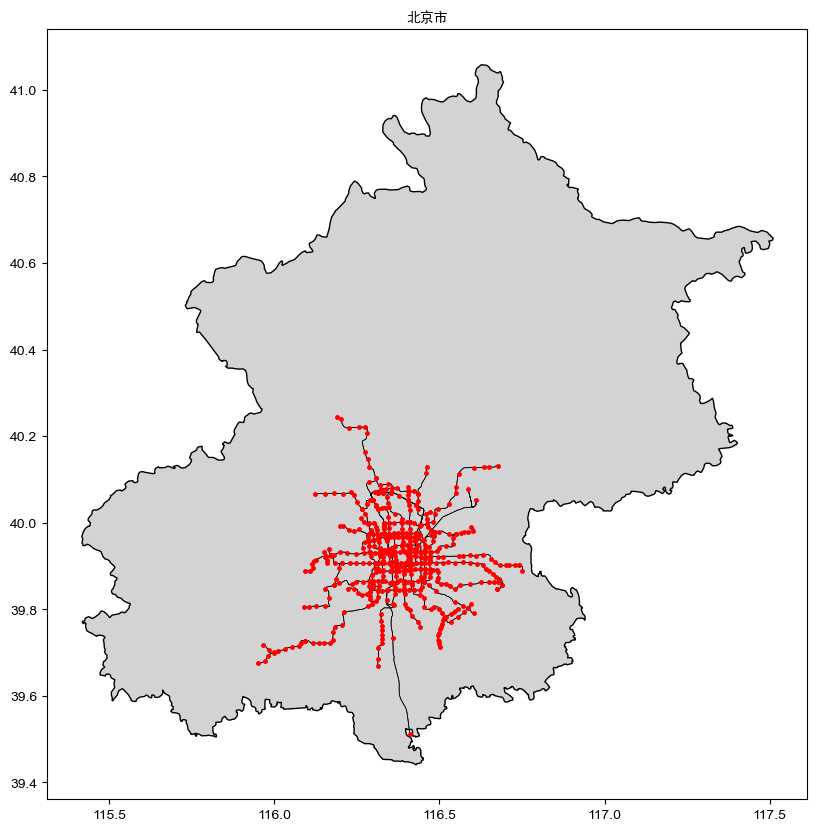

In [11]:
for name in df0["地名"].unique():
    fig, ax = plt.subplots(figsize=(10, 10))
    routes[routes["地名"] == name].plot(ax=ax, color="black", lw=0.5, zorder=2)
    stops[stops["地名"] == name].plot(ax=ax, color='red', markersize=5, zorder=3)
    city[city["地名"] == name].plot(ax=ax, color='lightgray', edgecolor='black', zorder=1)
    ax.set_title(name, fontproperties=heiti_font)
    plt.show()
    break

- 提取站点经纬度均值

<Axes: >

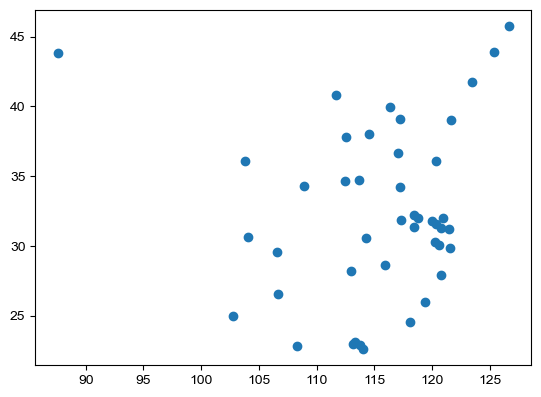

In [12]:
centers = gpd.GeoDataFrame(
    stops.groupby("地名")[["geometry"]].apply(
        lambda g: Point(g.geometry.x.mean(), g.geometry.y.mean())
    ).reset_index(name="geometry"), 
    geometry="geometry", 
    crs=routes.crs
)
centers.plot()

- 构建圆和正方形

In [13]:
radius = 0.55
buffer_c = gpd.GeoDataFrame(
    centers[["地名"]],
    geometry=centers.geometry.buffer(radius),
    crs=centers.crs
)

C:\Users\15499\AppData\Local\Temp\ipykernel_7936\3603183020.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geometry=centers.geometry.buffer(radius),


In [14]:
radius = 0.55
buffer_s = gpd.GeoDataFrame(
    centers[["地名"]],
    geometry=centers.geometry.buffer(radius, cap_style=3),
    crs=centers.crs
)

C:\Users\15499\AppData\Local\Temp\ipykernel_7936\1480034003.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geometry=centers.geometry.buffer(radius, cap_style=3),


<Axes: >

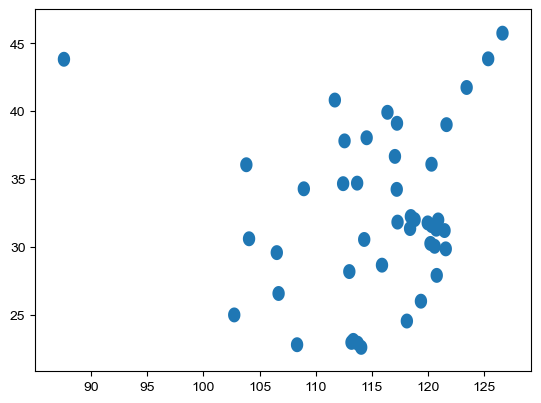

In [15]:
buffer_c.plot()

<Axes: >

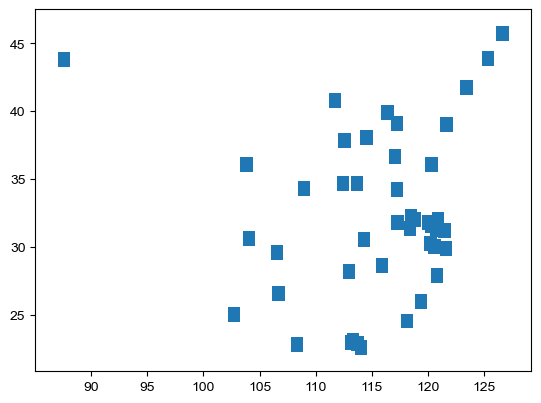

In [16]:
buffer_s.plot()

<Axes: >

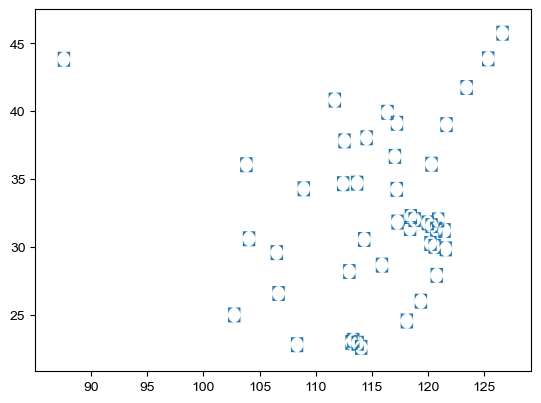

In [17]:
buffer_s1 = gpd.GeoDataFrame(
    centers[["地名"]],
    geometry=buffer_s.difference(buffer_c),
    crs=centers.crs
)
buffer_s1.plot()

In [18]:
routes_list = []
stops_list = []

for name in buffer_c["地名"].unique():
    buffer_single = buffer_c[buffer_c["地名"] == name][["geometry"]]
    
    if "地名" in routes.columns:
        routes_single = routes[routes["地名"] == name][["geometry", "地名"]]
    else:
        routes_single = routes.copy()
    
    if "地名" in stops.columns:
        stops_single = stops[stops["地名"] == name][["geometry", "地名"]]
    else:
        stops_single = stops.copy()
    

    if len(routes_single) > 0:
        routes_city = gpd.overlay(routes_single, buffer_single, how='intersection')
        routes_list.append(routes_city)
    
    if len(stops_single) > 0:
        stops_city = gpd.overlay(stops_single, buffer_single, how='intersection')
        stops_list.append(stops_city)

routes1 = pd.concat(routes_list, ignore_index=True) if routes_list else gpd.GeoDataFrame()
stops1 = pd.concat(stops_list, ignore_index=True) if stops_list else gpd.GeoDataFrame()

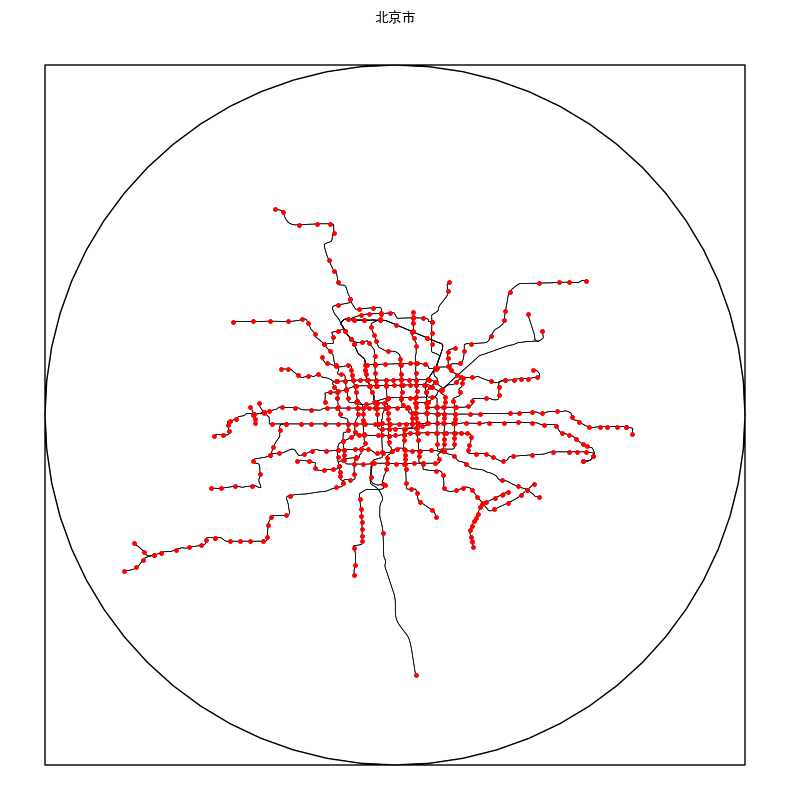

In [19]:
for name in df0["地名"].unique():
    fig, ax = plt.subplots(figsize=(10, 10))
    routes1[routes1["地名"] == name].plot(ax=ax, color="black", lw=0.5, zorder=2)
    stops1[stops1["地名"] == name].plot(ax=ax, color='red', markersize=5, zorder=3)
    buffer_s1[buffer_s1["地名"] == name].plot(ax=ax, color="white", ec="black", zorder=4)
    buffer_c[buffer_c["地名"] == name].boundary.plot(ax=ax, color="black", lw=0.5, zorder=1)
    ax.set_title(name, fontproperties=heiti_font)
    ax.set_aspect("equal")
    ax.axis("off")
    plt.show()

    break

## 提取人口数据

In [20]:
output_dir = "data/city_pop"
ds = gdal.Open(pop_path)
pop_crs = CRS.from_wkt(ds.GetProjection())
ds = None

d:\Anaconda3\envs\geo311\Lib\site-packages\osgeo\gdal.py:330: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


In [21]:
pop_crs

<Projected CRS: PROJCS["Albers_Conic_Equal_Area",GEOGCS["GCS_Krass ...>
Name: Albers_Conic_Equal_Area
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Albers Equal Area
Datum: unknown
- Ellipsoid: krass
- Prime Meridian: Greenwich

In [22]:
def clip_to_wgs84(raster, shp, out_clip, out_resampled, out_vis):

    nodata_val = -9999
    
    # 读取 raster CRS
    ds = gdal.Open(raster)
    raster_crs = CRS.from_wkt(ds.GetProjection())
    ds = None
    
    # shp 重投影
    gdf = gpd.read_file(shp).to_crs(raster_crs)
    tmp = "temp.shp"
    gdf.to_file(tmp)
    
    # 裁剪
    gdal.Warp(
        out_clip, 
        raster, 
        cutlineDSName=tmp, 
        cropToCutline=True, 
        # srcNodata=32767,
        dstNodata=nodata_val,
        outputType=gdal.GDT_Int32
    )

    # 重采样到1000m
    gdal.Warp(
        out_resampled, 
        out_clip, 
        xRes=1000, 
        yRes=1000, 
        resampleAlg=gdal.GRA_Sum,
        srcNodata=nodata_val,
        dstNodata=nodata_val
    )
    
    # 转展示坐标系
    gdal.Warp(
        out_vis,
        out_resampled,
        # out_clip,
        dstSRS="EPSG:4326",
        srcNodata=nodata_val,
        dstNodata=nodata_val
    )

In [23]:
for name in df0["地名"].unique():
    current_buffer = buffer_c[buffer_c["地名"] == name].to_crs(pop_crs)
    tmp = "data/temp.shp"
    current_buffer.to_file(tmp)

    out_clip = os.path.join(output_dir, f"{name}_clip.tif")
    out_resampled = os.path.join(output_dir, f"{name}_resampled.tif")
    out_vis = os.path.join(output_dir, f"{name}_wgs84.tif")

    clip_to_wgs84(pop_path, tmp, out_clip, out_resampled, out_vis)

    # 删除临时文件
    os.remove(out_clip)
    os.remove(out_resampled)


    print(f"{name} 处理完成")

北京市 处理完成
广州市 处理完成
上海市 处理完成
深圳市 处理完成
南京市 处理完成
武汉市 处理完成
杭州市 处理完成
成都市 处理完成
重庆市 处理完成
苏州市 处理完成
天津市 处理完成
沈阳市 处理完成
青岛市 处理完成
长沙市 处理完成
郑州市 处理完成
西安市 处理完成
厦门市 处理完成
无锡市 处理完成
昆明市 处理完成
福州市 处理完成
长春市 处理完成
南昌市 处理完成
大连市 处理完成
合肥市 处理完成
佛山市 处理完成
宁波市 处理完成
石家庄市 处理完成
济南市 处理完成
南宁市 处理完成
哈尔滨市 处理完成
绍兴市 处理完成
温州市 处理完成
南通市 处理完成
徐州市 处理完成
贵阳市 处理完成
乌鲁木齐市 处理完成
洛阳市 处理完成
兰州市 处理完成
滁州市 处理完成
芜湖市 处理完成
东莞市 处理完成
常州市 处理完成
呼和浩特市 处理完成
太原市 处理完成


## 制图

In [4]:
# routes1.to_file("data/metro_routes1.shp")
# stops1.to_file("data/metro_stops1.shp")
# buffer_s1.to_file("data/buffer_s.shp")
# buffer_c.to_file("data/buffer_c.shp")

pop_path = "data/city_pop"

routes1 = gpd.read_file("data/metro_routes1.shp")
stops1 = gpd.read_file("data/metro_stops1.shp")
buffer_s1 = gpd.read_file("data/buffer_s.shp")
buffer_c = gpd.read_file("data/buffer_c.shp")

data_crs = CRS.from_wkt(routes1.crs.to_wkt())
ctx.set_cache_dir("data/ctx_cache")

In [5]:
cmap = plt.get_cmap("Reds")
cmap.set_bad(color="none")

In [6]:
df0 = routes1.groupby("地名").size().reset_index(name="线路数").sort_values("线路数", ascending=False).reset_index(drop=True)
df0.head()

,地名,线路数
0,北京市,70
1,广州市,70
2,上海市,66
3,深圳市,53
4,南京市,44


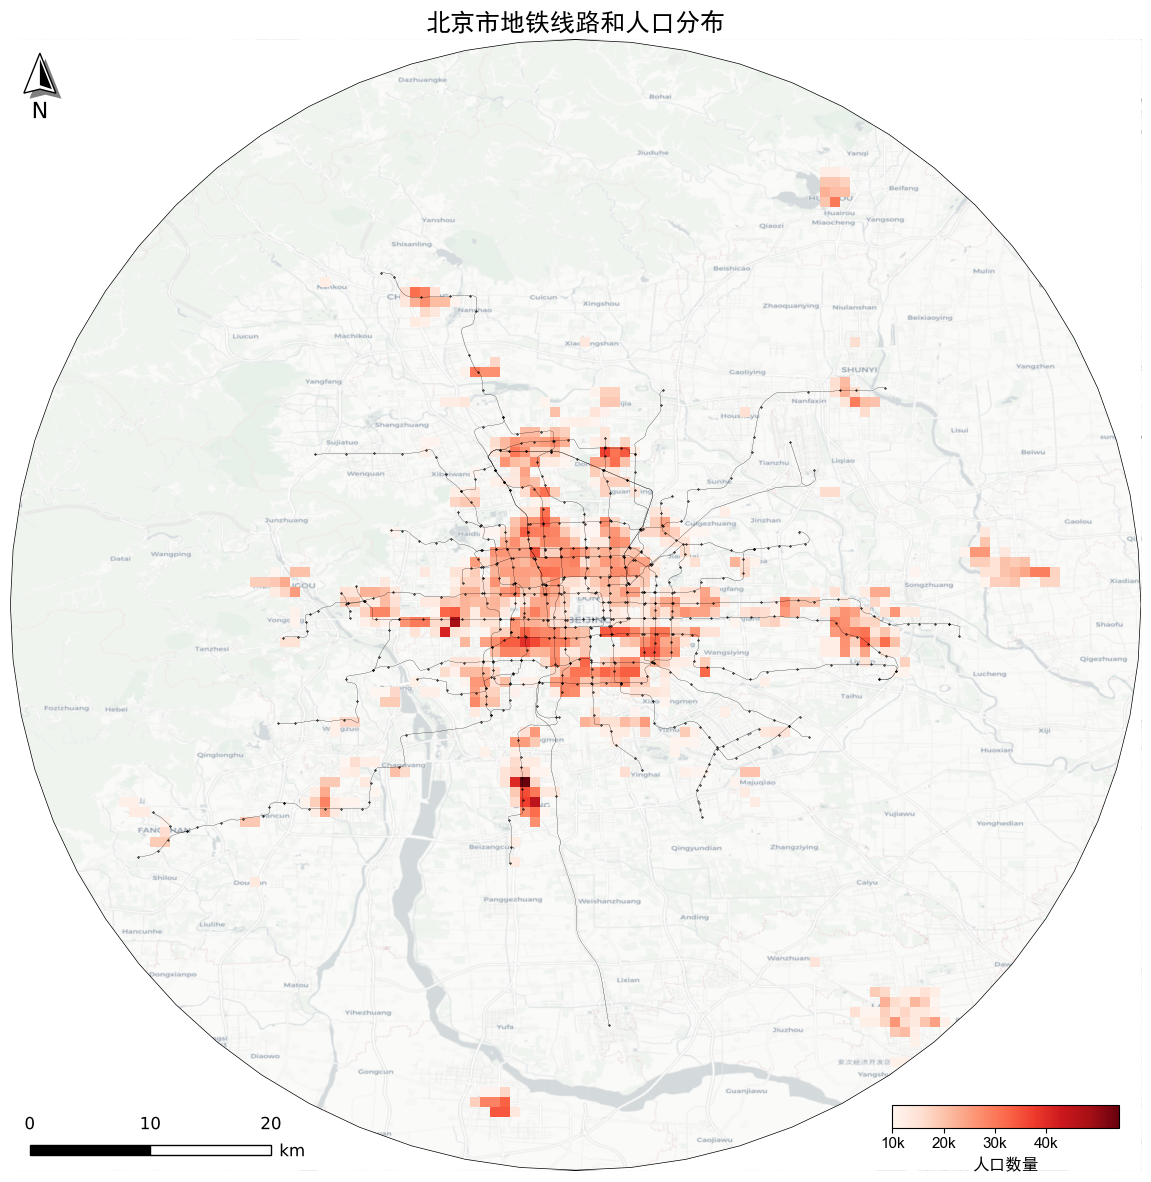

In [9]:
name = "北京市"
raster_file = os.path.join(pop_path, f"{name}_wgs84.tif")

with rasterio.open(raster_file) as src:
    data = src.read(1, masked=True)
    data = np.ma.masked_less_equal(data, 10000)
    left, bottom, right, top = src.bounds
    extent = [left, right, bottom, top]

vmin = 10000
vmax = np.percentile(data.compressed(), 100)
norm = Normalize(vmin=vmin, vmax=vmax)

fig, ax = plt.subplots(figsize=(12, 12))

# 栅格
img = ax.imshow(
    data,
    cmap=cmap,
    norm=norm,
    extent=extent,
    origin="upper",
    interpolation="none",
    alpha=1,
    zorder=1
)

# 矢量
routes1[routes1["地名"] == name].plot(ax=ax, color="black", lw=0.1, zorder=3)
stops1[stops1["地名"] == name].plot(ax=ax, color='black', markersize=0.1, zorder=4)
buffer_s1[buffer_s1["地名"] == name].plot(ax=ax, color="white", zorder=5)
buffer_c[buffer_c["地名"] == name].boundary.plot(ax=ax, color="black", lw=1, zorder=2)

# cbar
cax = ax.inset_axes(
    [0.78, 0.038, 0.2, 0.02],  # [x, y, width, height]（轴坐标）
    transform=ax.transAxes
)
cbar = plt.colorbar(
    img,
    cax=cax,
    orientation="horizontal"
)
cbar.set_label("人口数量", fontproperties=heiti_font, fontsize=12)
ticks = [10000, 20000, 30000, 40000]
cbar.set_ticks(ticks)
cbar.set_ticklabels([f"{int(t/1000)}k" for t in ticks])
cbar.ax.tick_params(labelsize=11)

# 比例尺指北针
scale_bar(
    ax=ax, 
    location="lower left", 
    style="boxes",
    bar={
        "projection": data_crs, 
        "max": 20,
        "major_div": 2,
        "minor_div": 1,
        "unit": "km"
    }
)
north_arrow(
    ax=ax, 
    location="upper left",
    rotation={
        "crs": data_crs, 
        "reference": "axis",
        "coords": (0.5,0.5)
    },
    scale=0.4
)

# 底图
contextily.add_basemap(
    ax=ax, 
    # source=contextily.providers.Esri.WorldGrayCanvas,
    # source=contextily.providers.Esri.WorldTerrain,
    source=ctx.providers.CartoDB.Positron,
    crs="epsg:4326",
    zorder=0, 
    zoom=11
)

# 提取buffer_s1的范围
minx, miny, maxx, maxy = buffer_s1[buffer_s1["地名"] == name].total_bounds
extent = [minx, maxx, miny, maxy]

ax.set_xlim(extent[0], extent[1])
ax.set_ylim(extent[2], extent[3])
ax.set_title(f"{name}地铁线路和人口分布", fontproperties=heiti_font, fontsize=18)
ax.set_aspect("equal")
ax.axis("off")

plt.tight_layout()
plt.savefig(f"fig/{name}.png", dpi=400)
plt.show()

In [ ]:
figed_city = []

for name in df0["地名"].unique():

    raster_file = os.path.join(pop_path, f"{name}_wgs84.tif")

    with rasterio.open(raster_file) as src:
        data = src.read(1, masked=True)
        data = np.ma.masked_less_equal(data, 10000)
        left, bottom, right, top = src.bounds
        extent = [left, right, bottom, top]

    vmin = 10000
    vmax = np.percentile(data.compressed(), 100)
    norm = Normalize(vmin=vmin, vmax=vmax)

    fig, ax = plt.subplots(figsize=(12, 12))

    # 栅格
    img = ax.imshow(
        data,
        cmap=cmap,
        norm=norm,
        extent=extent,
        origin="upper",
        interpolation="none",  # 'nearest', 'antialiased', 'hanning', 'kaiser', 'gaussian', 'quadric', 'blackman', 'spline16', 'mitchell', 'sinc', 'hamming', 'lanczos', 'bessel', 'bilinear', 'bicubic', 'hermite', 'auto', 'catrom', 'spline36', 'none'
        alpha=1,
        zorder=1
    )

    # 矢量
    routes1[routes1["地名"] == name].plot(ax=ax, color="black", lw=0.1, zorder=3)
    stops1[stops1["地名"] == name].plot(ax=ax, color='black', markersize=0.1, zorder=4)
    buffer_s1[buffer_s1["地名"] == name].plot(ax=ax, color="white", zorder=5)
    buffer_c[buffer_c["地名"] == name].boundary.plot(ax=ax, color="black", lw=1, zorder=2)

    # cbar
    cax = ax.inset_axes(
        [0.78, 0.038, 0.2, 0.02],  # [x, y, width, height]（轴坐标）
        transform=ax.transAxes
    )
    cbar = plt.colorbar(
        img,
        cax=cax,
        orientation="horizontal"
    )
    cbar.set_label("人口数量", fontproperties=heiti_font, fontsize=12)
    ticks = [10000, 20000, 30000, 40000]
    cbar.set_ticks(ticks)
    cbar.set_ticklabels([f"{int(t/1000)}k" for t in ticks])
    cbar.ax.tick_params(labelsize=11)

    # 比例尺指北针
    scale_bar(
        ax=ax, 
        location="lower left", 
        style="boxes",
        bar={
            "projection": data_crs, 
            "max": 20,
            "major_div": 2,
            "minor_div": 1,
            "unit": "km"
        }
    )
    north_arrow(
        ax=ax, 
        location="upper left",
        rotation={
            "crs": data_crs, 
            "reference": "axis",
            "coords": (0.5,0.5)
        },
        scale=0.4
    )

    # 底图
    contextily.add_basemap(
        ax=ax, 
        source=ctx.providers.CartoDB.Positron,
        crs="epsg:4326",
        zorder=0, 
        zoom=11
    )
    
    # 提取buffer_s1的范围
    minx, miny, maxx, maxy = buffer_s1[buffer_s1["地名"] == name].total_bounds
    extent = [minx, maxx, miny, maxy]

    ax.set_xlim(extent[0], extent[1])
    ax.set_ylim(extent[2], extent[3])
    ax.set_title(f"{name}地铁线路和人口分布", fontproperties=heiti_font, fontsize=18)
    ax.set_aspect("equal")
    ax.axis("off")

    plt.tight_layout()
    plt.savefig(f"fig/{name}.png", dpi=400)
    plt.close()

    
    figed_city.append(name)